In [1]:
# Install required libraries
!pip install pandas numpy scikit-learn xgboost catboost matplotlib seaborn joblib fastapi uvicorn openpyxl

  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)

   ---------------- ----------------------- 2/5 [uvicorn]
   ---------------- ----------------------- 2/5 [uvicorn]
   ------------------------ --------------- 3/5 [starlette]
   -------------------------------- ------- 4/5 [fastapi]
   -------------------------------- ------- 4/5 [fastapi]
   ---------------------------------------- 5/5 [fastapi]



In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [43]:
# ▶ UPDATE this path to your Excel file
FILE_PATH = 'data.xlsx'

df = pd.read_excel(FILE_PATH)
print(f'✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

✅ Data loaded: 100000 rows, 10 columns


,Branch,Gender,Age,Years_At_Company,Performance_Score,Monthly_Salary,average_Work_Hours_Per_Week,Overtime_Hours,Sick_Days,Employee_Satisfaction_Score
0,Head Office,Male,55,2,5,6750,33,22,2,2.63
1,Mathugama,Male,29,0,5,7500,34,13,14,1.72
2,Mathugama,Male,55,8,3,5850,37,6,3,3.17
3,Narammala,Female,48,7,2,4800,52,28,12,1.86
4,Melsiripura,Female,36,3,2,4800,38,29,13,1.25


In [44]:
# Basic info
print('=== COLUMN INFO ===')
df.info()
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())
print('\n=== STATISTICS ===')
df.describe()

=== COLUMN INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Branch                       100000 non-null  object 
 1   Gender                       100000 non-null  object 
 2   Age                          100000 non-null  int64  
 3   Years_At_Company             100000 non-null  int64  
 4   Performance_Score            100000 non-null  int64  
 5   Monthly_Salary               100000 non-null  int64  
 6   average_Work_Hours_Per_Week  100000 non-null  int64  
 7   Overtime_Hours               100000 non-null  int64  
 8   Sick_Days                    100000 non-null  int64  
 9   Employee_Satisfaction_Score  100000 non-null  float64
dtypes: float64(1), int64(7), object(2)
memory usage: 7.6+ MB

=== MISSING VALUES ===
Branch                         0
Gender                         0
Age       

,Age,Years_At_Company,Performance_Score,Monthly_Salary,average_Work_Hours_Per_Week,Overtime_Hours,Sick_Days,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.029410,4.278790,2.995430,6403.211000,44.956950,14.514930,7.008550,2.999088
std,11.244121,2.609413,1.414726,1372.508717,8.942003,8.664026,4.331591,1.150719
min,22.000000,0.000000,1.000000,3850.000000,30.000000,0.000000,0.000000,1.000000
25%,31.000000,2.000000,2.000000,5250.000000,37.000000,7.000000,3.000000,2.010000
50%,41.000000,4.000000,3.000000,6500.000000,45.000000,15.000000,7.000000,3.000000
75%,51.000000,7.000000,4.000000,7500.000000,53.000000,22.000000,11.000000,3.990000
max,60.000000,8.000000,5.000000,9000.000000,60.000000,29.000000,14.000000,5.000000


In [45]:
# Branch distribution
print('=== BRANCHES ===')
print(df['Branch'].value_counts())
print('\n=== GENDER ===')
print(df['Gender'].value_counts())

=== BRANCHES ===
Branch
Matara         11216
Mathugama      11200
Kottawa        11181
Head Office    11131
Mullaitivu     11122
Kandy          11118
Narammala      11116
Badulla        10960
Melsiripura    10956
Name: count, dtype: int64

=== GENDER ===
Gender
Male      48031
Female    48001
Other      3968
Name: count, dtype: int64


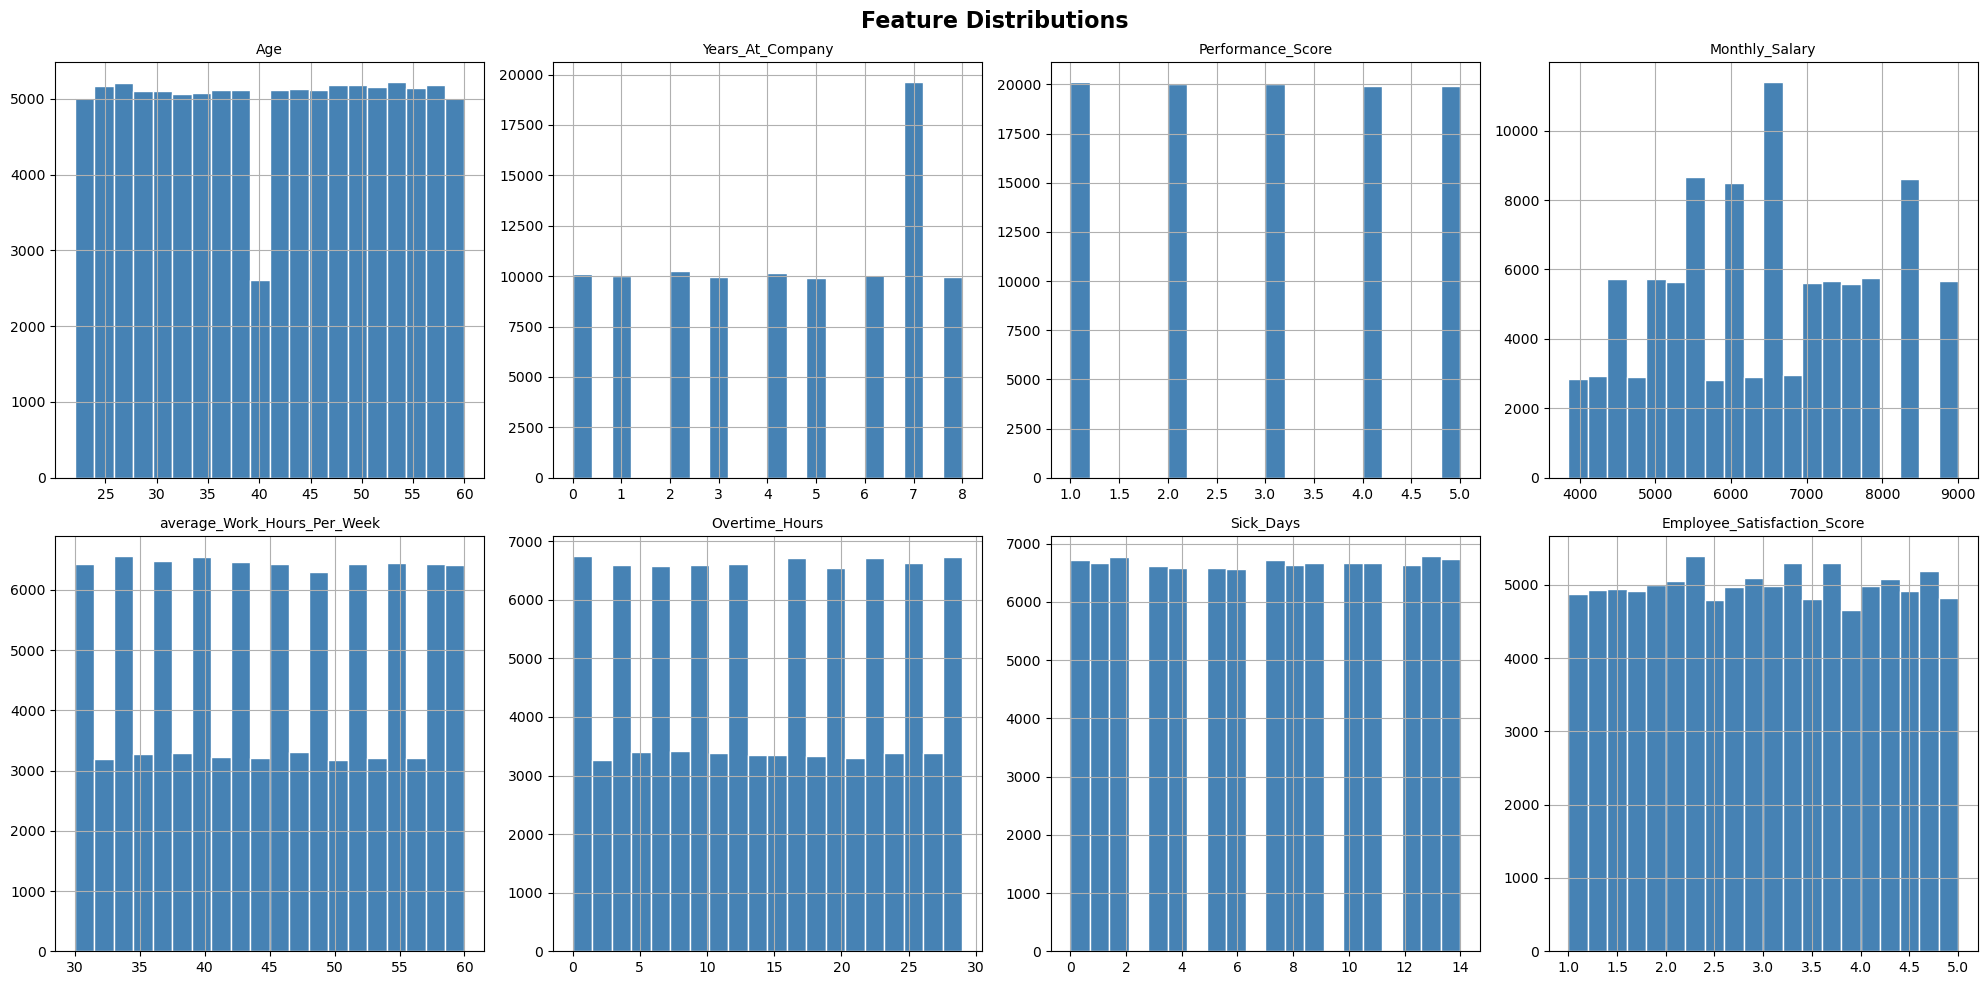

✅ Distribution plot saved!


In [46]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

num_cols = ['Age', 'Years_At_Company', 'Performance_Score', 'Monthly_Salary',
            'average_Work_Hours_Per_Week', 'Overtime_Hours', 'Sick_Days', 'Employee_Satisfaction_Score']

for i, col in enumerate(num_cols):
    ax = axes[i//4][i%4]
    df[col].hist(ax=ax, color='steelblue', edgecolor='white', bins=20)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Distribution plot saved!')

In [56]:
# Branch-wise performance
branch_stats = df.groupby('Branch')[['Performance_Score', 'Employee_Satisfaction_Score',
                                      'Monthly_Salary', 'Overtime_Hours', 'Sick_Days']].mean().round(2)
print('=== BRANCH-WISE AVERAGES ===')
branch_stats

=== BRANCH-WISE AVERAGES ===


,Performance_Score,Employee_Satisfaction_Score,Monthly_Salary,Overtime_Hours,Sick_Days
Branch,,,,,
Badulla,3.00,3.00,6400.36,14.58,7.04
Head Office,3.00,3.02,6414.60,14.67,6.99
Kandy,2.98,2.99,6391.28,14.55,6.94
Kottawa,3.01,3.03,6412.31,14.52,6.97
Matara,2.98,2.99,6377.86,14.48,6.97
Mathugama,2.98,3.00,6398.58,14.34,7.08
Melsiripura,3.02,3.00,6417.25,14.59,7.02
Mullaitivu,2.99,2.99,6413.15,14.51,7.01
Narammala,3.00,2.97,6403.88,14.38,7.06


In [57]:
df_ml = df.copy()

# --- Engineer Branch_Overall_Rating (Primary Target) ---
# Normalize components to 0-1 scale, then compute weighted composite
def normalize(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

perf_norm   = normalize(df_ml['Performance_Score'])
satis_norm  = normalize(df_ml['Employee_Satisfaction_Score'])
sick_norm   = normalize(df_ml['Sick_Days'])          # lower = better
ot_norm     = normalize(df_ml['Overtime_Hours'])     # lower = better
salary_norm = normalize(df_ml['Monthly_Salary'])

df_ml['Branch_Overall_Rating'] = (
    0.35 * perf_norm +
    0.30 * satis_norm +
    0.15 * salary_norm +
    0.10 * (1 - sick_norm) +
    0.10 * (1 - ot_norm)
).round(4)

# Scale to 1-10
df_ml['Branch_Overall_Rating'] = (df_ml['Branch_Overall_Rating'] * 9 + 1).round(2)

print('✅ Branch_Overall_Rating engineered (scale: 1-10)')
print(df_ml['Branch_Overall_Rating'].describe())

✅ Branch_Overall_Rating engineered (scale: 1-10)
count    100000.000000
mean          5.489056
std           1.592363
min           1.220000
25%           4.300000
50%           5.490000
75%           6.670000
max           9.990000
Name: Branch_Overall_Rating, dtype: float64


In [58]:
# --- Encode Categorical Variables ---
le_branch = LabelEncoder()
le_gender = LabelEncoder()

df_ml['Branch_Encoded'] = le_branch.fit_transform(df_ml['Branch'])
df_ml['Gender_Encoded'] = le_gender.fit_transform(df_ml['Gender'])

# Save encoders
joblib.dump(le_branch, 'le_branch.pkl')
joblib.dump(le_gender, 'le_gender.pkl')

print('✅ Encoders saved: le_branch.pkl, le_gender.pkl')
print('Branch classes:', list(le_branch.classes_))
print('Gender classes:', list(le_gender.classes_))

✅ Encoders saved: le_branch.pkl, le_gender.pkl
Branch classes: ['Badulla', 'Head Office', 'Kandy', 'Kottawa', 'Matara', 'Mathugama', 'Melsiripura', 'Mullaitivu', 'Narammala']
Gender classes: ['Female', 'Male', 'Other']


In [59]:
# --- Define Features ---
FEATURES = [
    'Branch_Encoded', 'Gender_Encoded', 'Age', 'Years_At_Company',
    'Monthly_Salary', 'average_Work_Hours_Per_Week',
    'Overtime_Hours', 'Sick_Days', 'Employee_Satisfaction_Score'
]

TARGETS = {
    'Performance_Score': 'Performance_Score'
}

X = df_ml[FEATURES]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, 'scaler.pkl')
print('✅ Scaler saved: scaler.pkl')
print(f'Feature matrix shape: {X_scaled.shape}')
print(f'Features used ({len(FEATURES)}): {FEATURES}')


✅ Scaler saved: scaler.pkl
Feature matrix shape: (100000, 9)
Features used (9): ['Branch_Encoded', 'Gender_Encoded', 'Age', 'Years_At_Company', 'Monthly_Salary', 'average_Work_Hours_Per_Week', 'Overtime_Hours', 'Sick_Days', 'Employee_Satisfaction_Score']


In [60]:
# --- Base Model Definitions (Hybrid blend: RF + XGBoost + CatBoost) ---
MODELS = {
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost':      XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, verbosity=0),
    'CatBoost':     CatBoostRegressor(iterations=200, depth=6, learning_rate=0.05, random_state=42, verbose=0),
}

print('✅ Base models defined!')
for name in MODELS:
    print(f'   • {name}')
print('\nHybrid strategy: R²-weighted average blend of all base models')


✅ Base models defined!
   • RandomForest
   • XGBoost
   • CatBoost

Hybrid strategy: R²-weighted average blend of all base models


In [61]:
# --- Train base models + build R²-weighted Hybrid ---
results = {}
trained_models = {}
hybrid_weights = {}

for target_name, target_col in TARGETS.items():
    y = df_ml[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    results[target_name] = {}
    trained_models[target_name] = {}
    base_preds = {}

    print(f'\n{"="*55}')
    print(f'🎯 TARGET: {target_name}')
    print(f'{"="*55}')

    # --- Train each base model ---
    for model_name, model in MODELS.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r2   = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)

        results[target_name][model_name] = {'R2': round(r2, 4), 'RMSE': round(rmse, 4), 'MAE': round(mae, 4)}
        trained_models[target_name][model_name] = model
        base_preds[model_name] = y_pred

        pkl_name = f'{model_name.lower()}_{target_name.lower()}.pkl'
        joblib.dump(model, pkl_name)
        print(f'  ✅ {model_name:15s} | R²: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} → saved {pkl_name}')

    # --- Build Hybrid: R²-weighted average blend ---
    # Use non-negative R² as weights; clip negative R² to 0
    r2_scores = {m: max(results[target_name][m]['R2'], 0) for m in MODELS}
    total_r2  = sum(r2_scores.values())
    weights   = {m: r2_scores[m] / total_r2 for m in MODELS}
    hybrid_weights[target_name] = weights

    hybrid_pred = sum(weights[m] * base_preds[m] for m in MODELS)
    h_r2   = r2_score(y_test, hybrid_pred)
    h_rmse = np.sqrt(mean_squared_error(y_test, hybrid_pred))
    h_mae  = mean_absolute_error(y_test, hybrid_pred)

    results[target_name]['Hybrid'] = {'R2': round(h_r2, 4), 'RMSE': round(h_rmse, 4), 'MAE': round(h_mae, 4)}
    print(f'\n  🔀 {"Hybrid":15s} | R²: {h_r2:.4f} | RMSE: {h_rmse:.4f} | MAE: {h_mae:.4f}')
    print(f'     Weights → ' + ' | '.join(f'{m}: {w:.3f}' for m, w in weights.items()))

    # Save hybrid weights
    joblib.dump(weights, f'hybrid_weights_{target_name.lower()}.pkl')
    print(f'  💾 Hybrid weights saved → hybrid_weights_{target_name.lower()}.pkl')

print('\n🎉 All base models + Hybrid trained and saved!')



🎯 TARGET: Performance_Score
  ✅ RandomForest    | R²: 0.9255 | RMSE: 0.3865 | MAE: 0.1363 → saved randomforest_performance_score.pkl
  ✅ XGBoost         | R²: 0.9256 | RMSE: 0.3861 | MAE: 0.1321 → saved xgboost_performance_score.pkl
  ✅ CatBoost        | R²: 0.9208 | RMSE: 0.3984 | MAE: 0.2071 → saved catboost_performance_score.pkl

  🔀 Hybrid          | R²: 0.9253 | RMSE: 0.3871 | MAE: 0.1578
     Weights → RandomForest: 0.334 | XGBoost: 0.334 | CatBoost: 0.332
  💾 Hybrid weights saved → hybrid_weights_performance_score.pkl

🎉 All base models + Hybrid trained and saved!


In [62]:
# Results summary table (base models + Hybrid)
rows = []
for target, models in results.items():
    for model, metrics in models.items():
        rows.append({'Target': target, 'Model': model, **metrics})

results_df = pd.DataFrame(rows)
print('=== MODEL PERFORMANCE SUMMARY ===')
results_df.sort_values(['Target', 'R2'], ascending=[True, False])


=== MODEL PERFORMANCE SUMMARY ===


,Target,Model,R2,RMSE,MAE
1,Performance_Score,XGBoost,0.9256,0.3861,0.1321
0,Performance_Score,RandomForest,0.9255,0.3865,0.1363
3,Performance_Score,Hybrid,0.9253,0.3871,0.1578
2,Performance_Score,CatBoost,0.9208,0.3984,0.2071


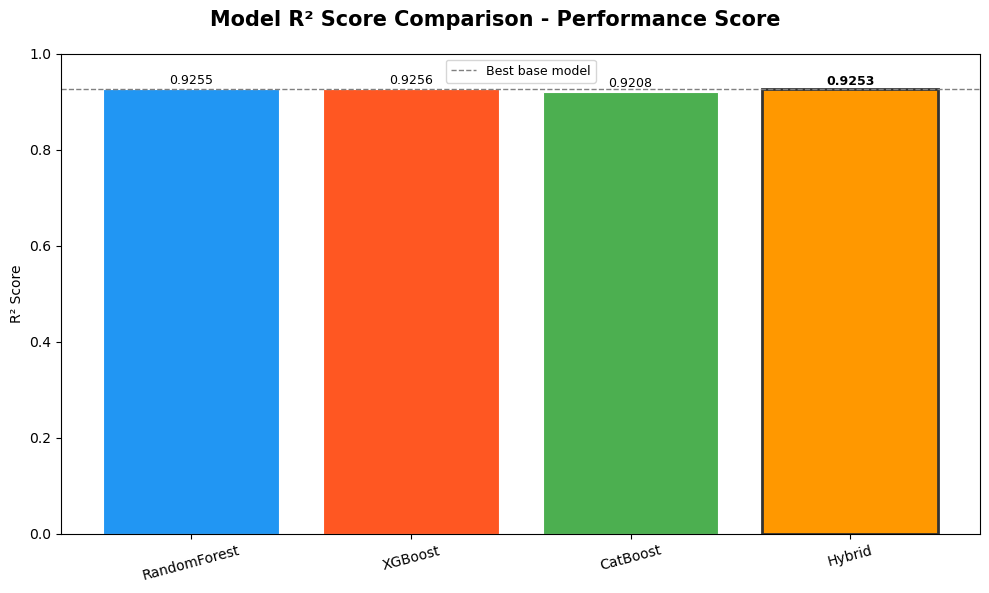

✅ Model comparison chart saved!


In [63]:
# R² comparison bar chart — base models vs Hybrid
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Model R² Score Comparison - Performance Score', fontsize=15, fontweight='bold')

target_df = results_df[results_df['Target'] == 'Performance_Score'].copy()
# Ensure Hybrid is last
order = ['RandomForest', 'XGBoost', 'CatBoost', 'Hybrid']
target_df = target_df.set_index('Model').reindex(order).reset_index()

colors = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800']
bars = ax.bar(target_df['Model'], target_df['R2'], color=colors, edgecolor='white', linewidth=0.8)

# Highlight Hybrid bar
bars[-1].set_edgecolor('#333')
bars[-1].set_linewidth(2)

ax.set_ylabel('R² Score')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=15)
for j, (_, row) in enumerate(target_df.iterrows()):
    ax.text(j, row['R2'] + 0.01, f"{row['R2']:.4f}", ha='center', fontsize=9,
            fontweight='bold' if row['Model'] == 'Hybrid' else 'normal')

ax.axhline(target_df[target_df['Model'] != 'Hybrid']['R2'].max(), color='gray',
           linestyle='--', linewidth=1, label='Best base model')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model comparison chart saved!')
